In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scanpy as sc
import squidpy as sq
from anndata import AnnData
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import sys
sys.path.append('..')
import cellrefiner as cr

/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [3]:
ad = sq.datasets.seqfish()
ad

AnnData object with n_obs × n_vars = 19416 × 351
    obs: 'Area', 'celltype_mapped_refined'
    uns: 'celltype_mapped_refined_colors'
    obsm: 'X_umap', 'spatial'

generate sc data

In [4]:
ad_sc=AnnData(ad.X)
ad_sc.obs_names=[f'Cell_{i}' for i in range(ad_sc.shape[0])]
ad_sc.var_names=ad.var_names
ad_sc.obsm['spatial']=ad.obsm['spatial']
ad_sc.obs['Cell_type']=pd.Categorical(ad.obs['celltype_mapped_refined'])

In [9]:
spatial_coords = ad.obsm['spatial']
x_min, x_max = spatial_coords[:, 0].min(), spatial_coords[:, 0].max()
print(x_min, x_max)

-2.5493682364864583 2.520293708124292


generate pseudo st data

In [15]:
spatial_coords = ad.obsm['spatial']

# Find 5 nearest neighbors for each cell
nbrs = NearestNeighbors(n_neighbors=6, algorithm='ball_tree').fit(spatial_coords)  # 6 because it includes the point itself
distances, indices = nbrs.kneighbors(spatial_coords)

# Calculate average distance between centers of groups
group_centers = []
for i in range(len(spatial_coords)):
    # Get the 5 nearest neighbors (excluding the point itself)
    neighbor_indices = indices[i][1:6]  # Skip the first one (itself)
    group_coords = spatial_coords[neighbor_indices]
    center = np.mean(group_coords, axis=0)
    group_centers.append(center)

group_centers = np.array(group_centers)

# Calculate distances between group centers
center_distances = cdist(group_centers, group_centers)
# Get average distance to nearest neighbors (excluding self)
d_avg = np.mean([np.sort(row)[1:6].mean() for row in center_distances])*3

print(f"Average distance between group centers: {d_avg}")

# Create grid with same x-y range as spatial coordinates
x_min, x_max = spatial_coords[:, 0].min(), spatial_coords[:, 0].max()
y_min, y_max = spatial_coords[:, 1].min(), spatial_coords[:, 1].max()

# Create grid points at intervals of d_avg
x_grid = np.arange(x_min, x_max + d_avg, d_avg)
y_grid = np.arange(y_min, y_max + d_avg, d_avg)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

print(f"Created {len(grid_points)} grid points")

# Assign cells to grid points
assigned_cells = {}  # grid_point_index -> list of cell_indices
radius_threshold = d_avg / 2

for grid_idx, grid_point in enumerate(grid_points):
    # Calculate distances from this grid point to all cells
    distances_to_cells = cdist([grid_point], spatial_coords)[0]
    
    # Find cells within radius threshold
    within_radius = np.where(distances_to_cells <= radius_threshold)[0]
    
    if len(within_radius) > 0:
        # Sort by distance and take up to 5 closest
        sorted_indices = within_radius[np.argsort(distances_to_cells[within_radius])]
        selected_cells = sorted_indices[:5]
        assigned_cells[grid_idx] = selected_cells

print(f"Grid points with assigned cells: {len(assigned_cells)}")

# Remove grid points with no assigned cells and create final grid
final_grid_points = []
final_assigned_cells = []

for grid_idx, cell_indices in assigned_cells.items():
    final_grid_points.append(grid_points[grid_idx])
    final_assigned_cells.append(cell_indices)

final_grid_points = np.array(final_grid_points)
print(f"Final number of grid points: {len(final_grid_points)}")

# Create spot by gene matrix by summing expression of assigned cells
X1 = []
for cell_indices in final_assigned_cells:
    # Sum the gene expression of assigned cells for this spot
    spot_expression = ad1.X[cell_indices].sum(axis=0)
    X1.append(spot_expression)

X1 = np.array(X1)
if hasattr(X1[0], 'A1'):  # Handle sparse matrices
    X1 = np.array([row.A1 if hasattr(row, 'A1') else row for row in X1])

# Ensure X1 is 2D by squeezing out any singleton dimensions
if X1.ndim == 3 and X1.shape[1] == 1:
    X1 = X1.squeeze(axis=1)

print(f"Created expression matrix with shape: {X1.shape}")

In [16]:
# Create new AnnData object
ad_st = AnnData(X=X1)
ad_st.obsm['spatial'] = final_grid_points
ad_st.var_names = ad.var_names
ad_st.obs_names = [f'spot_{i}' for i in range(len(final_grid_points))]

preprocess

In [17]:
sc.pp.filter_cells(ad_sc,min_genes=3)
sc.pp.filter_genes(ad_sc,min_cells=3)
sc.pp.normalize_total(ad_sc)
sc.pp.log1p(ad_sc)
sc.pp.highly_variable_genes(ad_sc)
ad_sc = ad_sc[:,ad_sc.var['highly_variable']]

run cellrefiner

In [18]:
db = pd.read_csv('LR.csv')
adata_cr = cr.pp.spatial_mapping(ad_st,ad_sc,db,scale=200,cluster_key_sc = 'Cell_type')

/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


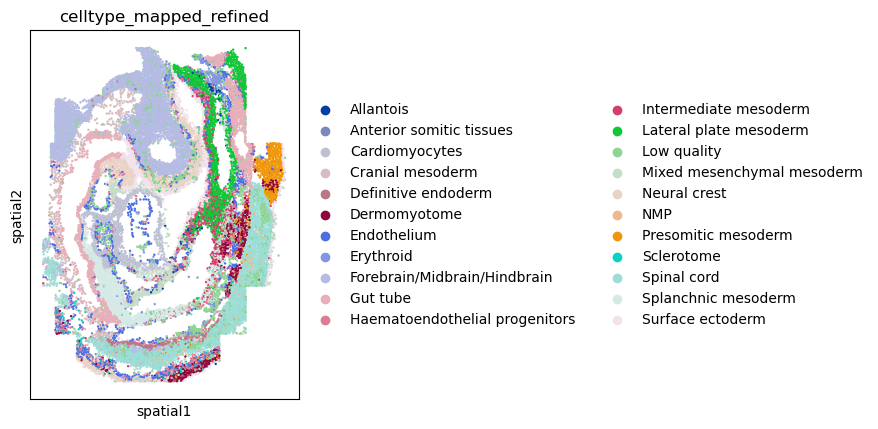

In [ ]:
sc.pl.spatial(ad,color = 'celltype_mapped_refined',spot_size = 0.05)
sc.pl.spatial(adata_cr,color = 'Cell_type',spot_size = 0.05,basis='spatial_cr')